# Managing Data Leakage

In this notebook, we demonstrate how an engineered feature containing future information creates a **target leakeage** pitfall for **data leakage**, inflating performance metrics that will poorly generalize to new data.

For further background please read [**What is data leakage in machine learning?**](https://www.ibm.com/think/topics/data-leakage-machine-learning) to deepen insights on data leakage.

In [ ]:
'''
Author : Arewa Morountudun Ojelade
Date : 8/26/2025
Organization : Miami Machine Learning
Sponsor : https://NeuralTransformers.org
'''

## Outline
- [ 1 - Kaggle Connection](#1)
- [ 2 - Pandas CSV Import](#2)
- [ 3 - Feature Engineering](#3)
- [ 4 - Preparing Dataset](#4)
  - [ 4.1 Visualizing Features in Dataset](#4.1)
- [ 5 - Comparing Linear Regression Models](#5)
  - [ 5.1 Training models with liner regression](#5.1)
  - [ 5.2 Calculating model metrics](#5.2)
  - [ 5.3 Visualizing metrics](#5.3)
  - [ 5.4 Comparing Feature Importance with SHAP](#5.4)
- [ 6 - Conclusion](#6)
- [ 7 - References](#7)



<a name="1"></a>
## 1 - Kaggle Connection

In [ ]:
# Reference [2]
# create a connection to google drive from google colab
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install -q kaggle

# make a kaggle directory
!mkdir ~/.

# copy kaggle.json file from your dedicated Kaggle drive folder to a local folder
!cp /content/drive/MyDrive//Kaggle/kaggle.json ~/.kaggle/

# ensure only user has access to the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# extract dataset using username from kaggle.json file and the prefered dataset
!kaggle datasets download username/dataset

<a name="2"></a>
## 2 - Pandas CSV Import

We are using the [Employers_data.csv](https://www.kaggle.com/datasets/gmudit/employer-data) for the data leakage demonstration.

---

In [61]:
import pandas as pd
import tensorflow_datasets as tfds
# Reference [4]
df = pd.read_csv("Employers_data.csv")
df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


<a name="3"></a>
## 3 - Feature Engineering

Here we are engineering a feature **End_of_Year_Evals** that contains information from the target **Salary**.

It is important to note that End_of_year_Evals will not always be available during time of prediction. Making this feature a great example for data leakage.


In [62]:
salary_min = df['Salary'].min()
salary_max =  df['Salary'].max()

original_df = df.copy()

print(f"Salary Feature Evaluation:")
print(f"Salary Min: {salary_min}")
print(f"Salary Max: {salary_max}")
print(f"Ideal Eval correlation split: {(salary_max - salary_min)/10}")

Salary Feature Evaluation:
Salary Min: 25000
Salary Max: 215000
Ideal Eval correlation split: 19000.0


In [63]:
# rounding split to an even 20,000 to simulate an eval structure from 0 to 10
df['End_of_Year_Evals'] = df['Salary']/20000
print(df['End_of_Year_Evals'])

0        4.50
1        9.75
2        1.75
3        3.75
4        3.50
        ...  
9995     9.25
9996     8.25
9997    10.00
9998     6.75
9999     3.50
Name: End_of_Year_Evals, Length: 10000, dtype: float64


In [64]:
print(df.head())

   Employee_ID            Name  Age  Gender   Department  Job_Title  \
0            1    Merle Ingram   24  Female  Engineering   Engineer   
1            2      John Mayes   56    Male        Sales  Executive   
2            3    Carlos Wille   21    Male  Engineering     Intern   
3            4  Michael Bryant   30    Male      Finance    Analyst   
4            5   Paula Douglas   25  Female           HR    Analyst   

   Experience_Years Education_Level  Location  Salary  End_of_Year_Evals  
0                 1          Master    Austin   90000               4.50  
1                33          Master   Seattle  195000               9.75  
2                 1        Bachelor  New York   35000               1.75  
3                 9        Bachelor  New York   75000               3.75  
4                 2          Master   Seattle   70000               3.50  


<a name="4"></a>
## 4 - Preparing Dataset

In [65]:
df = df.drop(columns=['Name', 'Gender'])

print(df.head())

   Employee_ID  Age   Department  Job_Title  Experience_Years Education_Level  \
0            1   24  Engineering   Engineer                 1          Master   
1            2   56        Sales  Executive                33          Master   
2            3   21  Engineering     Intern                 1        Bachelor   
3            4   30      Finance    Analyst                 9        Bachelor   
4            5   25           HR    Analyst                 2          Master   

   Location  Salary  End_of_Year_Evals  
0    Austin   90000               4.50  
1   Seattle  195000               9.75  
2  New York   35000               1.75  
3  New York   75000               3.75  
4   Seattle   70000               3.50  


In [67]:
target = 'Salary'
columns = df.drop(columns = ['Employee_ID','Salary', 'Location']).columns.to_numpy()
print(columns)

['Age' 'Department' 'Job_Title' 'Experience_Years' 'Education_Level'
 'End_of_Year_Evals']


<a name="4.1"></a>
### 4.1 - Visualizing Features in Dataset

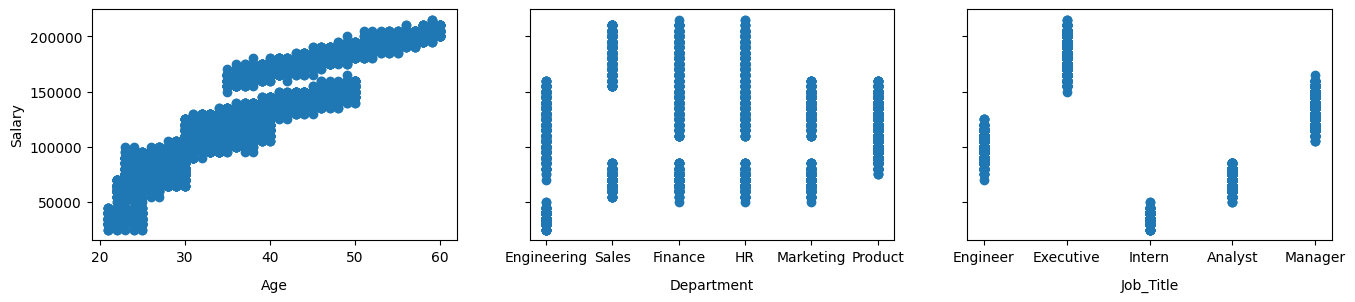

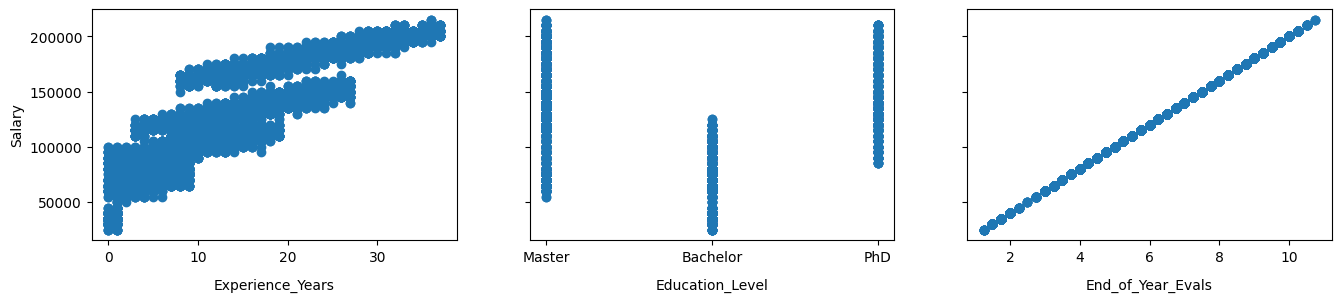

In [68]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2, suppress=True)
fig, ax=plt.subplots(1, 3, figsize = (16,3), sharey = True)

values = list(zip(range(len(ax)), columns[:3]))
for i, col in values:
  x = df[col].to_numpy()
  y = df[target].to_numpy()
  ax[i].scatter(x, y)
  ax[i].set_xlabel(col, labelpad =10)
ax[0].set_ylabel(target)
plt.show()
fig, ax=plt.subplots(1, 3, figsize = (16,3), sharey = True)

values = list(zip(range(len(ax)), columns[3:]))
for i, col in values:
  x = df[col].to_numpy()
  y = df[target].to_numpy()
  ax[i].scatter(x, y,)
  ax[i].set_xlabel(col, labelpad =10)
ax[0].set_ylabel(target)
plt.show()

In [70]:
# Reference [3]
# Call function to one hot encode contents of a dataframe column
def onehot_encode(df, column):
    return pd.Categorical(df[column]).codes


In [71]:
# Reference [3]
# Here we one hot encode our categorical data
str_cols = [col for col in df.select_dtypes(['object', 'string']).columns if col != target]
for col in str_cols:
  df[col] = onehot_encode(df, col)
print(df.head())

   Employee_ID  Age  Department  Job_Title  Experience_Years  Education_Level  \
0            1   24           0          1                 1                1   
1            2   56           5          2                33                1   
2            3   21           0          3                 1                0   
3            4   30           1          0                 9                0   
4            5   25           2          0                 2                1   

   Location  Salary  End_of_Year_Evals  
0         0   90000               4.50  
1         4  195000               9.75  
2         2   35000               1.75  
3         2   75000               3.75  
4         4   70000               3.50  


In [72]:
from sklearn.model_selection import train_test_split
# Splitting dataset to contain leaked feature for model 1
x1 = df.drop(columns = 'Salary')
y = df['Salary'].to_numpy()
x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y, test_size=0.2, random_state=42)


In [73]:
# Splitting dataset to contain only original features for model 2
x2 = df.drop(columns = ['Salary','End_of_Year_Evals'])
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y, test_size=0.2, random_state=42)


<a name="5"></a>
## 5 - Comparing Linear Regression Models

<a name="5.1"></a>
### 5.1 - Training models with Linear Regression
---

Trainig Model 1 (Data containing leaked feature) and generating predictions

In [74]:
from sklearn import linear_model
model1 = linear_model.LinearRegression()
model1.fit(x_train1, y_train1)
predictions1 = model1.predict(x_test1)


Trainig Model 2 (Original Data) and generating predictions

In [75]:
model2 = linear_model.LinearRegression()
model2.fit(x_train2, y_train2)
predictions2 = model2.predict(x_test2)


<a name="5.2"></a
### 5.2 - Calculating model metrics
---

In [76]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Evaluate model 1
r2_1 = r2_score(y_test1, predictions1)
mae_1 = mean_absolute_error(y_test1, predictions1)
mse_1 = mean_squared_error(y_test1, predictions1)

# Evaluate model 2
r2_2 = r2_score(y_test2, predictions2)
mae_2 = mean_absolute_error(y_test2, predictions2)
mse_2 = mean_squared_error(y_test2, predictions2)

print(f"Model 1 Evaluation:")
print(f"R2 Accuracy Score: {r2_1}")
print(f"Mean Absolute Error: {mae_1}")
print(f"Mean Squared Error: {mse_1}")

print(f"\nModel 2 Evaluation:")
print(f"R2 Accuracy Score: {r2_2}")
print(f"Mean Absolute Error: {mae_2}")
print(f"Mean Squared Error: {mse_2}")


print(f"\nR2 Score difference:")
print(f"R2 difference: {(r2_1 - r2_2)* 100 : .2f}%")

Model 1 Evaluation:
R2 Accuracy Score: 1.0
Mean Absolute Error: 3.439756255829707e-09
Mean Squared Error: 1.571296102688527e-17

Model 2 Evaluation:
R2 Accuracy Score: 0.8973766615441547
Mean Absolute Error: 11535.331500640263
Mean Squared Error: 216295310.13512775

R2 Score difference:
R2 difference:  10.26%


<a name="5.3"></a>
### 5.3 - Visualizing model metrics
---

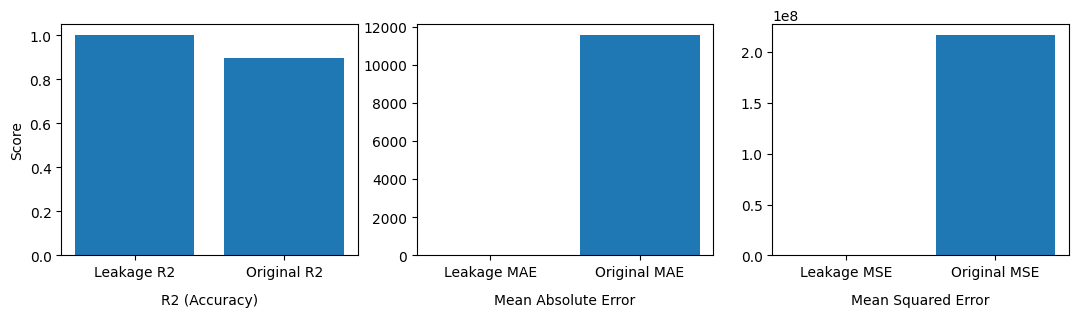

In [77]:
# Reference [1]
fig, ax=plt.subplots(1, 3, figsize = (13, 3))
values = [[r2_1, r2_2], [mae_1, mae_2], [mse_1, mse_2]]
metrics_name = ["R2 (Accuracy)", "Mean Absolute Error", "Mean Squared Error"]
metrics_list = [["Leakage R2", "Original R2"], ["Leakage MAE", "Original MAE"],
                ["Leakage MSE", "Original MSE"]]

for i, metrics, value in list(zip(range(len(values)),metrics_list,values)):
  x = metrics
  y = value
  ax[i].bar(x, y)
  ax[i].set_xlabel(metrics_name[i], labelpad =10)
ax[0].set_ylabel("Score")
plt.show()


<a name="5.4"></a>
### 5.4 - Comparing Feature Importance with SHAP
---

Here we use SHAP compare the **feature importance** between model 1 containing the leaked feature and model 2 with the original features. [3]

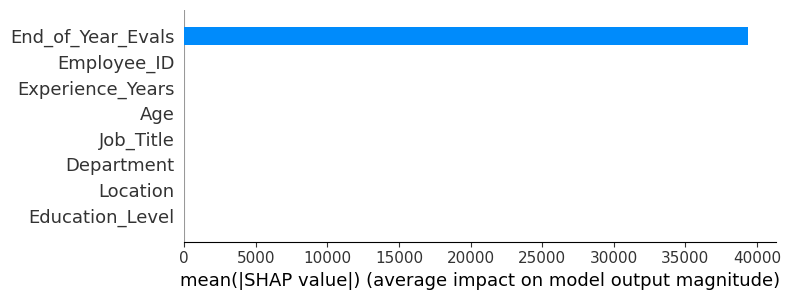

In [78]:
# Reference[3]
import shap
explainer = shap.LinearExplainer(model1, x1)
shap_values = explainer.shap_values(x1)

import warnings
warnings.filterwarnings('ignore')
shap.initjs()
shap.summary_plot(shap_values, x1, plot_size=0.2, plot_type='bar')

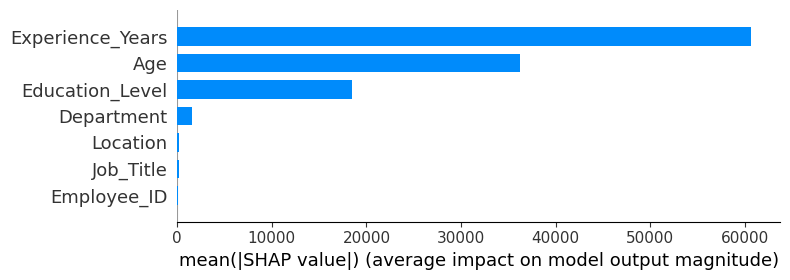

In [79]:
# Refence[3]
explainer = shap.LinearExplainer(model2, x2)
shap_values = explainer.shap_values(x2)

shap.initjs()
shap.summary_plot(shap_values, x2, plot_size=0.2, plot_type='bar')

<a name="6"></a>
## 6 - Conclusion

What impact does leakage such as this have on an organization? [7]

1. **Unreliable insights and fidings**: A 10.26% difference in accuracy can be  distructive. For example if the target variable is extremly large such as millions in dollars or pounds in cost of supplies, it can can create potential loss in profits.

      * This example showcases an overfitting symptom of data leakage. It is also possible for the symptom to be an underfitting model. In a scenario where the target is projected demand, an underfitted model will leave an organization ill equiped to meet up to the actual demands.

2. **Inflated performance metrics**: As the graph above shows the leakage model's error is negligible. Engineers are expecting perfect accuracy and will share that with analysts who will in turn present that to stock holders. This leads to disappointment when the actual MAE is 11,535.33 and MSE is 216,295,310.13.

3. **Waste of Resources**: The expenditure of resources required to find and fix data leakage after model training is costly. Sometimes retraining models from scrach is necessary and  computationally
expensive.


<a name="7"></a>
## 7 - References

[1] DeepLearning.AI. (2018). Supervised Machine Learning: Regression and Classification. Coursera. https://www.coursera.org/learn/machine-learning/lecture/erGPe/the-problem-of-overfitting

[2]DigitalSreeni. (2022, May 20). Loading Kaggle data directly into Google Colab. YouTube. https://www.youtube.com/watch?v=yEXkEUqK52Q

[3] Explainable AI with Synthetic Data. (2019). Google.com. https://colab.research.google.com/github/mostly-ai/mostly-tutorials/blob/dev/explainable-ai/explainable-ai.ipynb#scrollTo=uUvsR-mWBoNS

[4] Gaur, M. (2024). Employee Data. Kaggle.com. https://www.kaggle.com/datasets/gmudit/employer-data

[5] GOYAL, C. (2021, July 23). Data Leakage And Its Effect On The Performance of An ML Model. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2021/07/data-leakage-and-its-effect-on-the-performance-of-an-ml-model/

[6] Megaladata. (2023, December 20). Data Leakage in Machine Learning. Megaladata.com. https://megaladata.com/blog/data-leakage-machine-learning

[7] Mucci, T. (2024, September 30). Data leakage machine learning. Ibm.com. https://www.ibm.com/think/topics/data-leakage-machine-learning

[8] scikit-learn developers. (2019). sklearn.linear_model.LinearRegression — scikit-learn 0.22 documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html